# 新型增强量子表示（Novel Enhanced Quantum Representation，NEQR）

**新型增强量子表示**（NEQR）是量子图像表示的另一种早期形式。它类似于其前身量子图像的灵活表示（FRQI）[1]，因为它使用归一化叠加来存储图像中的像素。FRQI的局限性在于它使用一个量子比特来存储像素的灰度信息，这阻止了执行任何复杂的图像变换。NEQR的创建是为了通过利用量子比特序列的基态来存储图像的灰度值来改进FRQI[5]。

NEQR相对于FRQI提供了以下优势，如[5]中所示：

- 准备NEQR量子图像的时间复杂度具有二次加速  
- 高达1.5倍的最佳图像压缩比
- 测量后精确的图像检索，而不是像FRQI那样的概率性
- 可以实现复杂的颜色和许多其他操作

在本节中，我们将使用NEQR模型在量子计算机中表示一个经典的2×2灰度图像。

# 1. NEQR 过程

NEQR 过程用于表示量子计算机上的图像，由两部分组成：编码和压缩，具体描述如下。

## 1.1 当前图像编码方式：

为了使用 NEQR 模型在量子计算机上表示图像，我们首先要了解实现这一目标所需的各种组件以及它们之间的关系。我们从图像的色彩范围开始。

图像的色彩范围用二进制字符串表示，具体如下：
二值图像：1 位表示 0=黑色，1=白色

灰度图像：8 位表示从 0（黑色）到 255（白色）之间的各种灰度强度值。

彩色图像：24 位，分为 3 组 8 位，每组 8 位表示像素颜色的红、绿、蓝强度。

在我们的示例中，我们将根据像素在图像中的位置来表示它们。由于我们将表示二维图像，因此我们将分别用行和列（Y 和 X）来定义图像的位置。

## 1.2 图像压缩：

完成图像的量子表示后，我们将检查生成线路的深度和大小，并提供一些经典选项来压缩生成的 NEQR 线路。

现在，让我们开始编码一个 2×2 的量子图像。

# 2. 编码 2×2 图像

在本例中，我们将编码一个 2×2 的灰度图像，其中每个像素值包含以下值。在下表中，第一列表示 2×2 图像的像素位置。第二列表示指定像素位置的灰度强度值。第三列是对灰度强度的描述（例如：01100100 = 100）。

| 位置   | 二进制字符串 | 灰度强度     |
|--------|--------------|--------------|
| $\ket{00}$ | $\ket{00000000}$ | 0 - 黑色     |
| $\ket{01}$ | $\ket{01100100}$ | 100 - 深灰色 |
| $\ket{10}$ | $\ket{11001000}$ | 200 - 浅灰色 |
| $\ket{11}$ | $\ket{11111111}$ | 255 - 白色   |

为了编码这些像素，我们需要定义量子寄存器，第一个寄存器用于存储像素位置。由于这是一个二维图像，我们需要两个变量，一个与水平（列）相关，另一个与垂直（行）相关，分别是 Y 和 X。

每个像素的颜色值表示为 $\mathcal{f}(Y,X)$ ，其中 Y 和 X 分别通过行和列指定图像中的像素位置。

每个像素的灰度强度范围可能有所不同，但由于最常见的灰度范围通常为 0-255，因此该值通常表示为 $2^{q}$，对于 256，我们可以确认 $q=8$。其中 $q$ 表示颜色二进制序列所需的位数：$C^{0}, C^{1},... C^{q-2}, C^{q-1}$。

这意味着每个像素值可以表示如下，其中 C 是灰度强度值的二进制表示：

$$
\mathcal{f}(Y,X) = C^{0}_{YX}, C^{1}_{YX},... C^{q-2}_{YX}, C^{q-1}_{YX} \in [0,1], \;\; f(Y,X)\in[0, 2^{q-1}]
$$ 
例如，对于位置 (1,0) 且颜色强度为 100 (01100100) 的像素，它将表示如下：

$$
\mathcal{f}(1,0) = \overline{C^{0}_{10}}, C^{1}_{10}, C^{2}_{10}, \overline{C^{3}_{10}}, \overline{C^{4}_{10}}, C^{5}_{10}, \overline{C^{6}_{10}}, \overline{C^{7}_{10}} = 01100100 = 100
$$

因此，表示 $2^{n}×2^{n}$ 量子图像 $|I\rangle$ 的一般表达式为：

$$
|I\rangle = \frac{1}{2^{n}}\sum_{Y=0}^{2^{2n-1}} \sum_{X=0}^{2^{2n-1}} | \mathcal{f}(Y,X)\rangle |Y X\rangle = \frac{1}{2^{n}}\sum_{Y=0}^{2^{2n-1}} \sum_{X=0}^{2^{2n-1}} \vert\otimes_{i=0}^{q-1}\rangle |C_{YX}^{i}\rangle |Y X\rangle
$$

将上述方程转化为我们 2×2 示例像素值的结果如下：

$$
\mathsf{\Omega}_{YX}|0\rangle^{\otimes q} = \frac{1}{\sqrt[]{2}}(|00000000\rangle |00\rangle + |01100100\rangle |01\rangle + |11001000\rangle |10\rangle + |11111111\rangle |11\rangle)
$$

其中 $\mathsf{\Omega}_{YX}|0\rangle$ 是表示位置 (Y，X) 处像素值设置的量子操作。

## 2.1 创建图像的量子线路

我们首先使用编码图像所需的特定量子位数创建量子线路。为此，让我们创建两个独立的量子线路，一个用于标记为像素值，另一个用于标记为像素位置。

我们的第一个量子线路将包括用于表示像素值 $f(Y,X)$ 的 $2^n$ 量子位，在本例中将有 8 个量子位。

接下来，我们将 Hadamard 门添加到位置量子位，以便我们可以利用 2×2 图像中的所有位置。

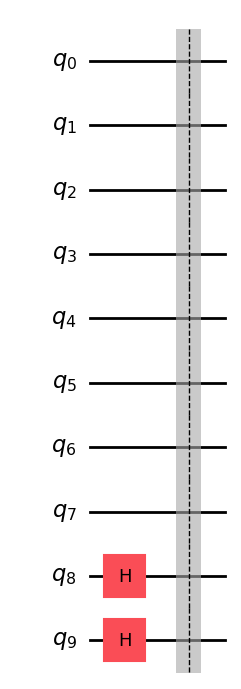

In [2]:
import deepquantum as dq
import numpy as np
import matplotlib.pyplot as plt

theta = 0

cir = dq.QubitCircuit(10)

cir.hlayer(wires=[8,9])

cir.barrier()

cir.draw()

## 2.2 量子线路上灰度图像的表示

现在我们已经创建并初始化了量子线路，让我们首先将像素位置线路与其各自的像素强度值结合在一起来准备线路。

现在让我们编码像素值。回想一下，我们为每个像素设置的值如下：

00 = 00000000（黑色）

01 = 01100100（灰度 = 100）

10 = 11001000（灰度 = 200）

11 = 11111111（白色）

因此，我们将从位置 (0,0) 的第一个像素开始。注意到我们的值都是 0，因此我们可以将其留空。

接下来，我们将编码第二个像素 (0,1)，其值为 (01010101)。在这里，我们将使用带有两个量子位控制的受控非门（2-CNOT），其中控制由像素位置 (Y,X) 触发，目标旋转表示像素值的 $C^{i}_{YX}$ 量子位。

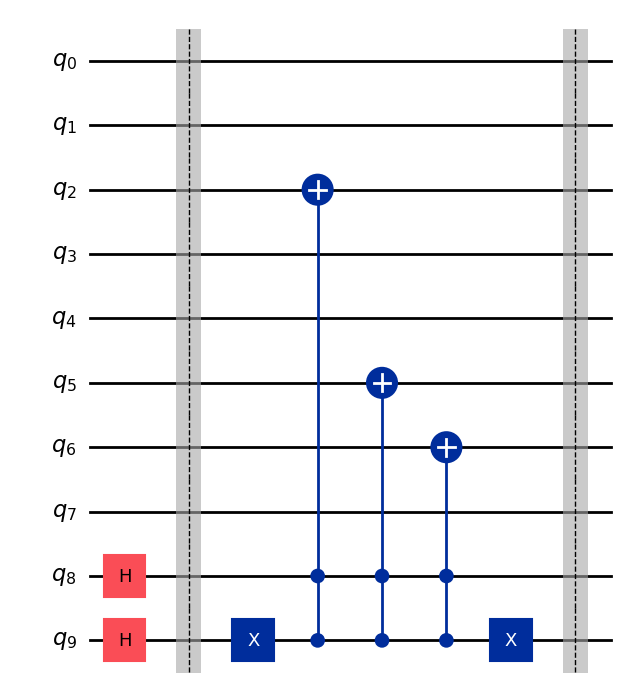

In [4]:
import deepquantum as dq
import numpy as np
import matplotlib.pyplot as plt

value01 = '01100100'

theta = 0
num_qubits = 10

cir = dq.QubitCircuit(num_qubits)

cir.hlayer(wires=[num_qubits-2,num_qubits-1])

cir.barrier()

cir.x(num_qubits-1)

for idx, px_value in enumerate(value01[::-1]):
    if(px_value=='1'):
        cir.ccx(num_qubits-1, num_qubits-2, idx)

cir.x(num_qubits-1)

cir.barrier()
cir.draw()

我们现在继续编码位置 (1,0) 的下一个像素，其值为 (10101010)。

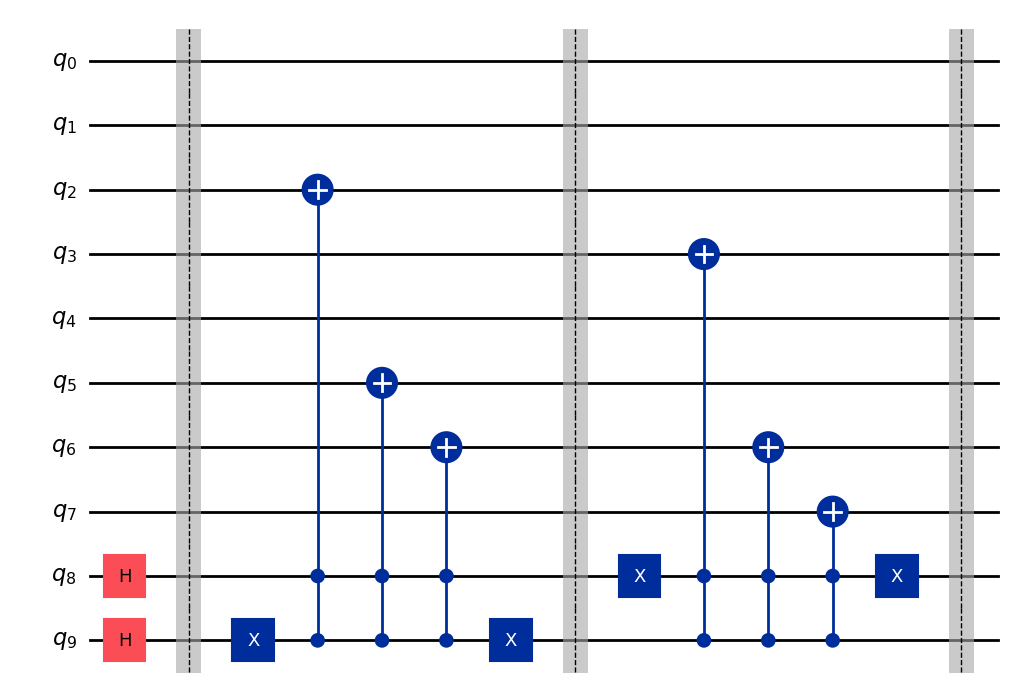

In [5]:
value10 = '11001000'

cir.x(num_qubits-2)

for idx, px_value in enumerate(value10[::-1]):
    if(px_value=='1'):
        cir.ccx(num_qubits-1, num_qubits-2, idx)

cir.x(num_qubits-2)
cir.barrier()
cir.draw()

最后，让我们完成编码最后一个像素位置 (1,1)，其值为 (11111111)。我们只需将 Toffoli 门添加到所有像素图像值即可完成。我们已成功编码了一个 2×2 像素的灰度图像。

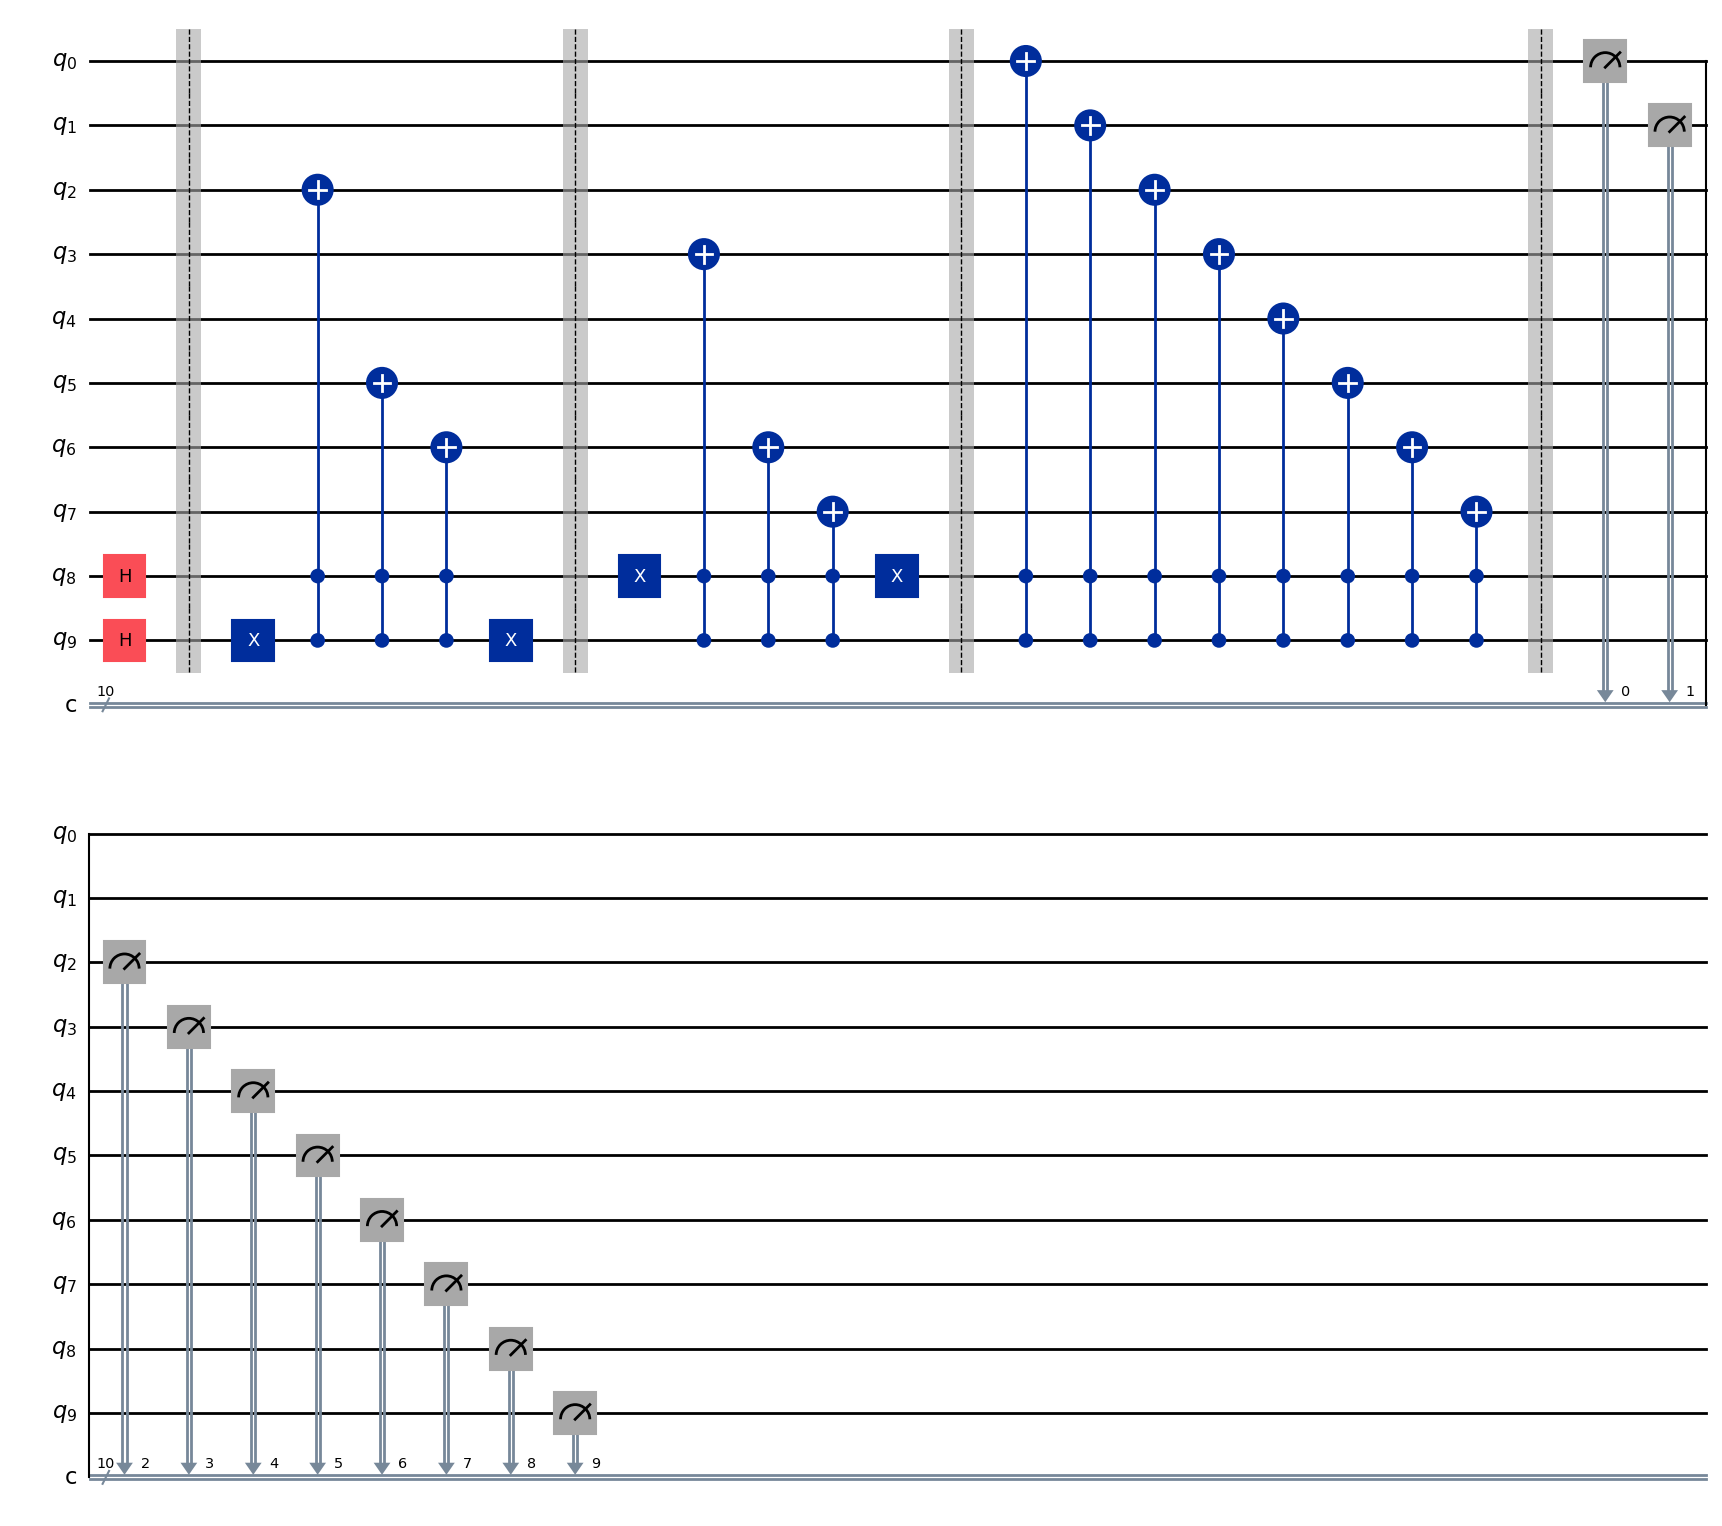

In [6]:
value11 = '11111111'

for idx, px_value in enumerate(value11[::-1]):
    if(px_value=='1'):
        cir.ccx(num_qubits-1, num_qubits-2, idx)

cir.barrier()
cir.measure()
cir.draw()


## 2.3 测量结果分析


{'1111111111': (248, tensor(0.2500)), '0001001101': (237, tensor(0.2500)), '0000000000': (272, tensor(0.2500)), '0010011010': (267, tensor(0.2500))}


<BarContainer object of 4 artists>

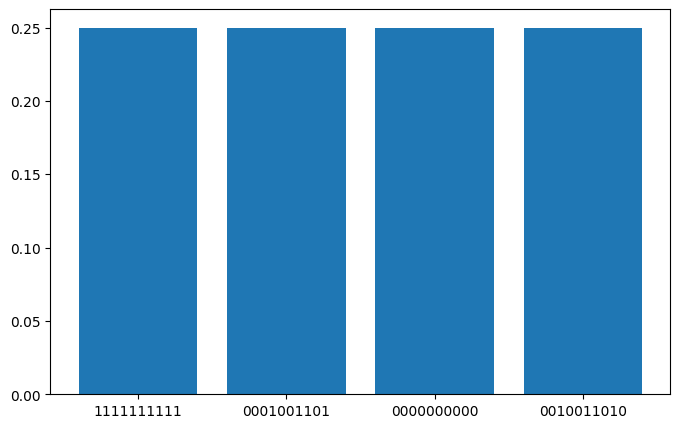

In [7]:
cir()

res=cir.measure(with_prob= True) # 打印测量结果
print(res)

# 将数据分解为X和Y轴的值
labels = list(res.keys())
values = [value[1] for value in res.values()]

# 创建条形图
plt.figure(figsize=(8, 5))  # 设置图形大小
plt.bar(labels, values)  # 绘制条形图


从上面的结果可以看出，像素位置由最左边的两个比特（00,01,10,11）表示，其余比特值表示灰度强度值的8位二进制表示，如下所示的编码结果：

编码:**00** = 00000000,
编码:**01** = 01100100, 
编码:**10** = 11001000,
编码:**11** = 11111111

# 参考文献

[1] Le, P.Q., Dong, F. & Hirota, K. A flexible representation of quantum images for polynomial preparation, image compression, and processing operations. Quantum Inf Process 10, 63–84 (2011). https://doi.org/10.1007/s11128-010-0177-y 

[2] Zhang, Y., Lu, K., Gao, Y. et al. _NEQR: a novel enhanced quantum representation of digital images._ Quantum Inf Process 12, 2833–2860 (2013). https://doi.org/10.1007/s11128-013-0567-z